In [1]:
import os

os.getcwd()

'/project/nr_haml2025/endomet/irwl1-adaptation/notebooks'

In [24]:
import pandas

df = pandas.read_csv("../results/resnet20_pruning_config_summary.csv")

In [25]:
df

,configuration,num_runs,epochs_to_target_mean,epochs_to_target_std,iterations_to_target_mean,iterations_to_target_std,avg_training_length_mean,avg_training_length_std,avg_regularization_length_mean,avg_regularization_length_std,sparsity_reached_mean,sparsity_reached_std,test_accuracy_mean,test_accuracy_std
0,smooth_rewind,5,661.8,3.271085,8.0,0.0,18.800,0.370810,61.875,0.250000,92.103730,0.060572,67.194,1.427386
1,smooth_no_rewind,5,884.8,16.006249,8.0,0.0,46.450,2.066473,61.950,0.360122,92.096707,0.071777,67.316,3.933857
2,static_rewind,5,449.6,6.188699,8.0,0.0,19.175,0.504666,34.750,0.385276,92.208326,0.039139,66.108,0.895863
3,static_no_rewind,5,671.2,6.906519,8.0,0.0,47.525,0.714799,34.250,0.293151,92.144522,0.043735,69.734,2.204094


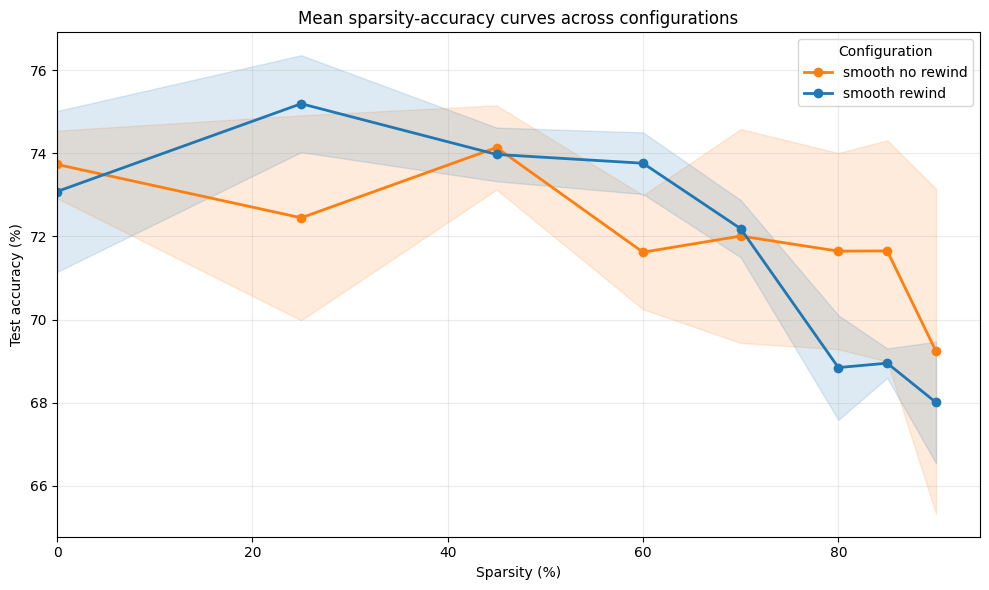

,configuration,sparsity_group,mean_accuracy,std_accuracy,num_points
0,smooth_no_rewind,0.0,73.730,0.812619,5
1,smooth_no_rewind,25.0,72.446,2.464839,5
2,smooth_no_rewind,45.0,74.136,1.013277,5
3,smooth_no_rewind,60.0,71.618,1.372432,5
4,smooth_no_rewind,70.0,72.008,2.571949,5
5,smooth_no_rewind,80.0,71.644,2.360144,5
6,smooth_no_rewind,85.0,71.650,2.659492,5
7,smooth_no_rewind,90.0,69.236,3.908925,10
8,smooth_rewind,0.0,73.078,1.934908,5
9,smooth_rewind,25.0,75.190,1.165311,5


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

all_checkpoints = pd.read_csv("../results/resnet20_pruning_all_checkpoints.csv")

# Group checkpoints that are within 2 percentage points of each other by rounding to the nearest 2% bin.
# This keeps the 0% checkpoint and aligns the sparsity points across runs even when the exact values differ slightly.
all_checkpoints = all_checkpoints.copy()
all_checkpoints["sparsity_group"] = (all_checkpoints["sparsity"] / 5.0).round() * 5.0
all_checkpoints["sparsity_group"] = all_checkpoints["sparsity_group"].clip(lower=0.0)

summary = (
    all_checkpoints
    .groupby(["configuration", "sparsity_group"], as_index=False)
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", lambda values: values.std(ddof=1)),
        num_points=("accuracy", "size"),
    )
    .sort_values(["configuration", "sparsity_group"])
)

fig, ax = plt.subplots(figsize=(10, 6))
config_colors = {
    "smooth_rewind": "tab:blue",
    "smooth_no_rewind": "tab:orange",
    "static_rewind": "tab:green",
    "static_no_rewind": "tab:red",
}

# filter configurations
summary = summary[summary["configuration"].isin(["smooth_rewind", "smooth_no_rewind"])]

for config_name, config_df in summary.groupby("configuration"):
    config_df = config_df.sort_values("sparsity_group")
    x = config_df["sparsity_group"].to_numpy()
    y = config_df["mean_accuracy"].to_numpy()
    yerr = config_df["std_accuracy"].fillna(0.0).to_numpy()

    ax.plot(
        x,
        y,
        marker="o",
        linewidth=2,
        label=config_name.replace("_", " "),
        color=config_colors.get(config_name),
    )
    ax.fill_between(
        x,
        y - yerr,
        y + yerr,
        alpha=0.15,
        color=config_colors.get(config_name),
    )

ax.set_xlabel("Sparsity (%)")
ax.set_ylabel("Test accuracy (%)")
ax.set_title("Mean sparsity-accuracy curves across configurations")
ax.grid(True, alpha=0.25)
ax.legend(title="Configuration")
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

summary


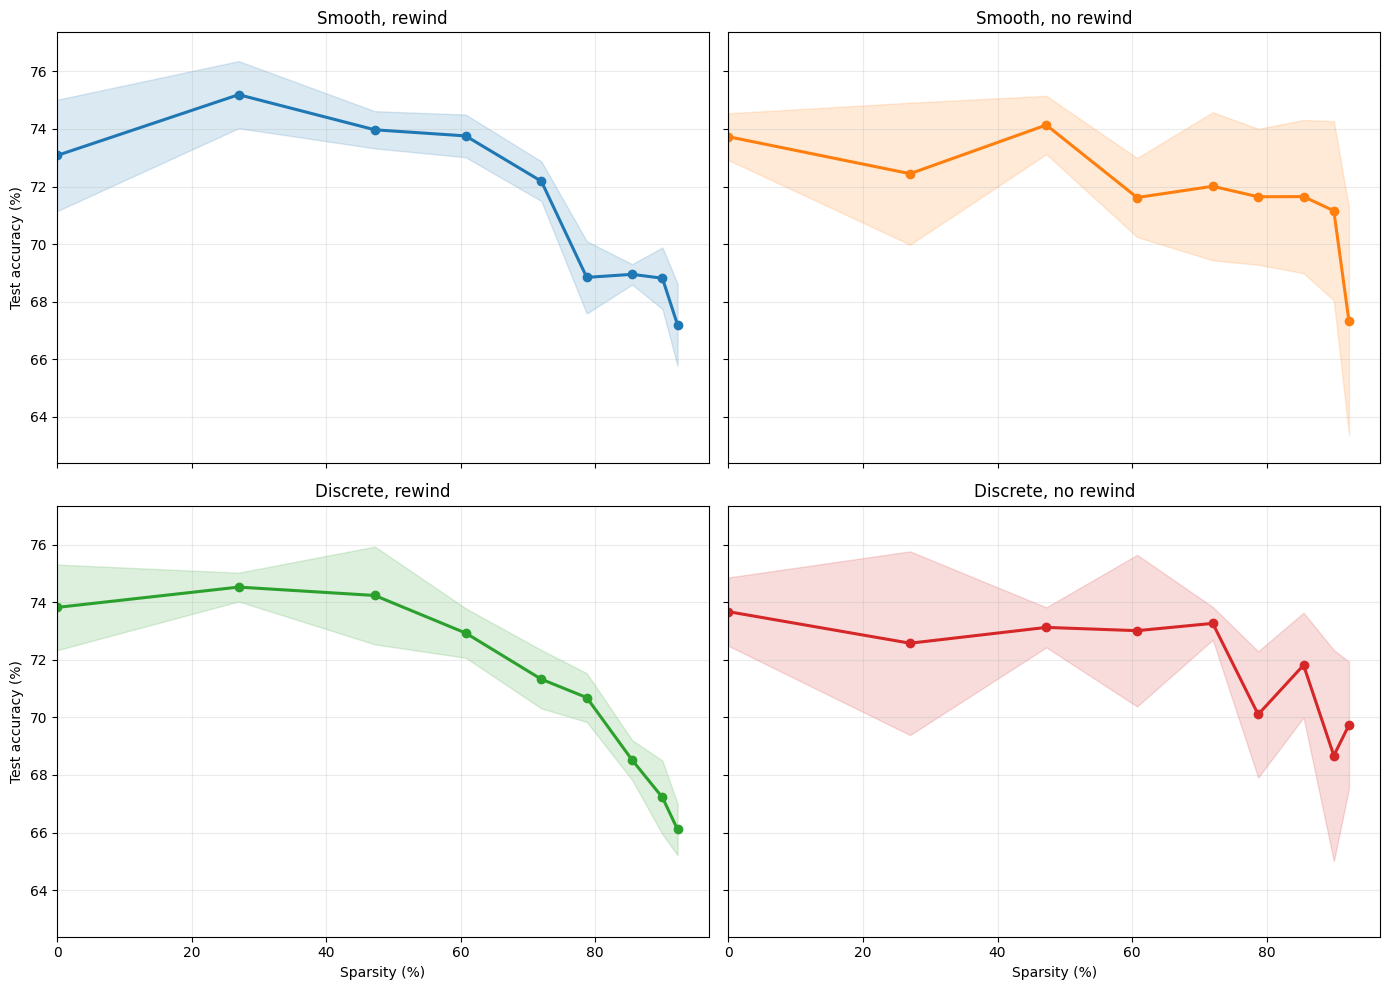

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

checkpoint_df = pd.read_csv("../results/resnet20_pruning_all_checkpoints.csv").copy()
checkpoint_df["sparsity_group"] = (checkpoint_df["sparsity"] / 2.25).round() * 2.25
checkpoint_df["sparsity_group"] = checkpoint_df["sparsity_group"].clip(lower=0.0)


comparison_summary = (
    checkpoint_df
    .groupby(["configuration", "sparsity_group"], as_index=False)
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", lambda values: values.std(ddof=1)),
        num_points=("accuracy", "size"),
    )
    .sort_values(["configuration", "sparsity_group"])
)

config_colors = {
    "smooth_rewind": "tab:blue",
    "smooth_no_rewind": "tab:orange",
    "static_rewind": "tab:green",
    "static_no_rewind": "tab:red",
}

config_layout = [
    ("smooth_rewind", "Smooth, rewind"),
    ("smooth_no_rewind", "Smooth, no rewind"),
    ("static_rewind", "Discrete, rewind"),
    ("static_no_rewind", "Discrete, no rewind"),
]

all_y = comparison_summary["mean_accuracy"].to_numpy()
all_yerr = comparison_summary["std_accuracy"].fillna(0.0).to_numpy()
ymin = float(np.min(all_y - all_yerr)) - 1.0
ymax = float(np.max(all_y + all_yerr)) + 1.0

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.ravel()

for ax, (config_name, title) in zip(axes, config_layout):
    config_df = comparison_summary[comparison_summary["configuration"] == config_name].sort_values("sparsity_group")
    x = config_df["sparsity_group"].to_numpy()
    y = config_df["mean_accuracy"].to_numpy()
    yerr = config_df["std_accuracy"].fillna(0.0).to_numpy()
    color = config_colors[config_name]

    ax.plot(x, y, marker="o", linewidth=2.2, color=color)
    ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.16)
    ax.set_title(title)
    ax.set_xlim(left=0)
    ax.set_ylim(ymin, ymax)
    ax.grid(True, alpha=0.25)

for ax in axes[2:]:
    ax.set_xlabel("Sparsity (%)")
for ax in axes[::2]:
    ax.set_ylabel("Test accuracy (%)")

#fig.suptitle("Sparsity-accuracy curves by configuration", y=1.02)
fig.tight_layout()
plt.show()

#comparison_summary


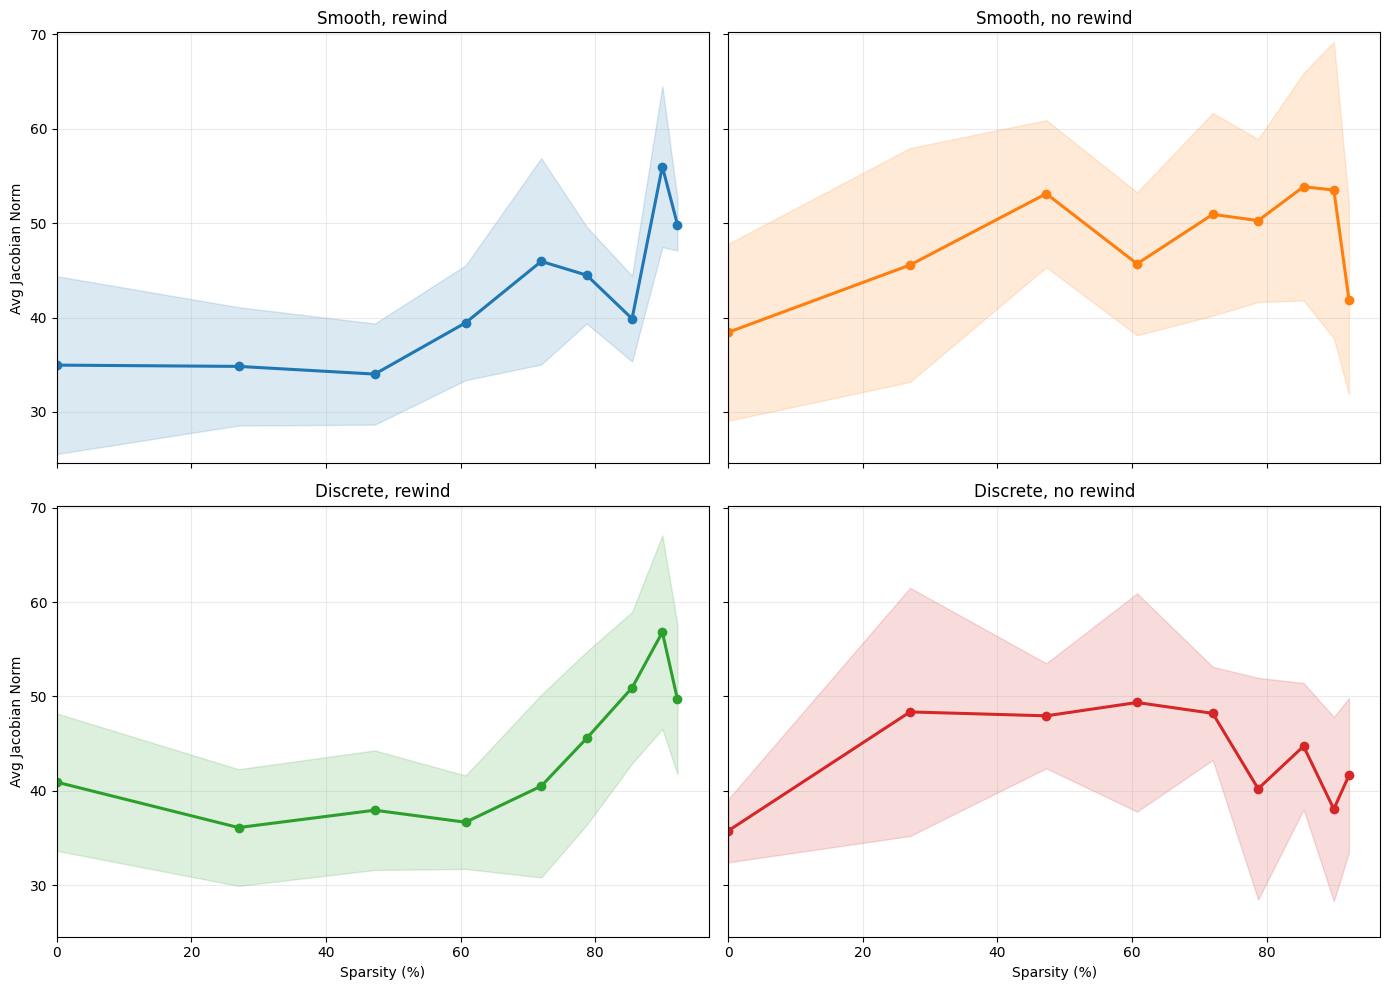

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

checkpoint_df = pd.read_csv("../results/resnet20_pruning_all_checkpoints.csv").copy()
checkpoint_df["sparsity_group"] = (checkpoint_df["sparsity"] / 2.25).round() * 2.25
checkpoint_df["sparsity_group"] = checkpoint_df["sparsity_group"].clip(lower=0.0)

target_column = "avg_jacobian_norm"  # Change this to "avg_jacobian_norm" to plot that metric instead
comparison_summary = (
    checkpoint_df
    .groupby(["configuration", "sparsity_group"], as_index=False)
    .agg(
        mean_accuracy=(f"{target_column}", "mean"),
        std_accuracy=(f"{target_column}", lambda values: values.std(ddof=1)),
        num_points=(f"{target_column}", "size"),
    )
    .sort_values(["configuration", "sparsity_group"])
)

config_colors = {
    "smooth_rewind": "tab:blue",
    "smooth_no_rewind": "tab:orange",
    "static_rewind": "tab:green",
    "static_no_rewind": "tab:red",
}

config_layout = [
    ("smooth_rewind", "Smooth, rewind"),
    ("smooth_no_rewind", "Smooth, no rewind"),
    ("static_rewind", "Discrete, rewind"),
    ("static_no_rewind", "Discrete, no rewind"),
]

all_y = comparison_summary["mean_accuracy"].to_numpy()
all_yerr = comparison_summary["std_accuracy"].fillna(0.0).to_numpy()
ymin = float(np.min(all_y - all_yerr)) - 1.0
ymax = float(np.max(all_y + all_yerr)) + 1.0

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.ravel()

for ax, (config_name, title) in zip(axes, config_layout):
    config_df = comparison_summary[comparison_summary["configuration"] == config_name].sort_values("sparsity_group")
    x = config_df["sparsity_group"].to_numpy()
    y = config_df["mean_accuracy"].to_numpy()
    yerr = config_df["std_accuracy"].fillna(0.0).to_numpy()
    color = config_colors[config_name]

    ax.plot(x, y, marker="o", linewidth=2.2, color=color)
    ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.16)
    ax.set_title(title)
    ax.set_xlim(left=0)
    ax.set_ylim(ymin, ymax)
    ax.grid(True, alpha=0.25)

for ax in axes[2:]:
    ax.set_xlabel("Sparsity (%)")
for ax in axes[::2]:
    ax.set_ylabel(f"{target_column.replace('_', ' ').title()}")

#fig.suptitle("Sparsity-accuracy curves by configuration", y=1.02)
fig.tight_layout()
plt.show()

#comparison_summary


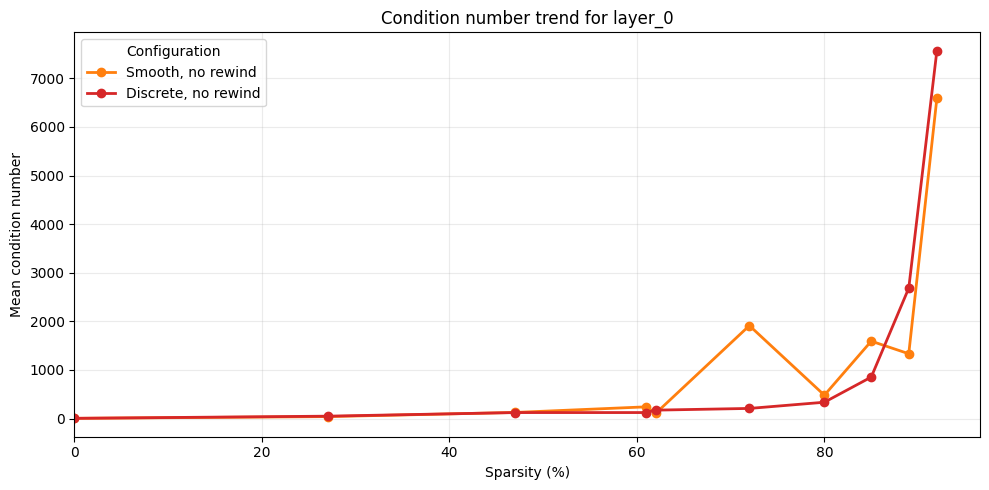

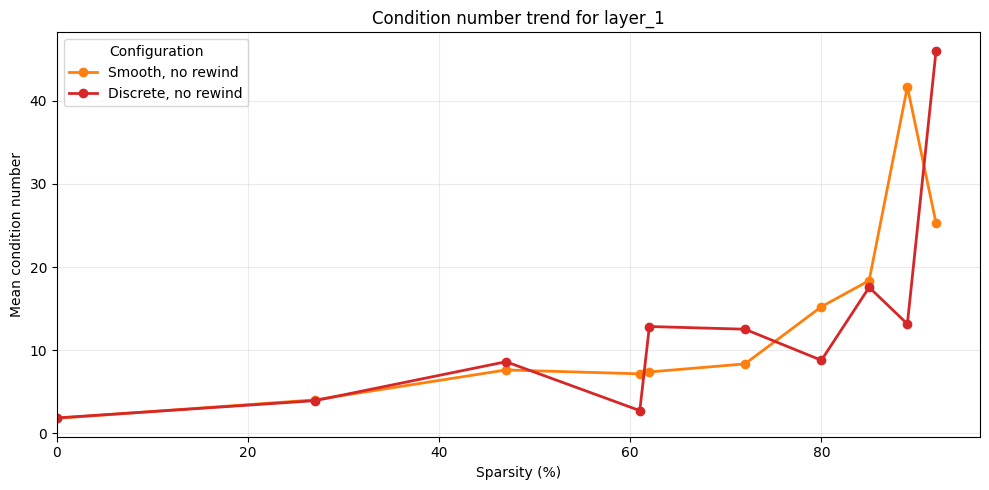

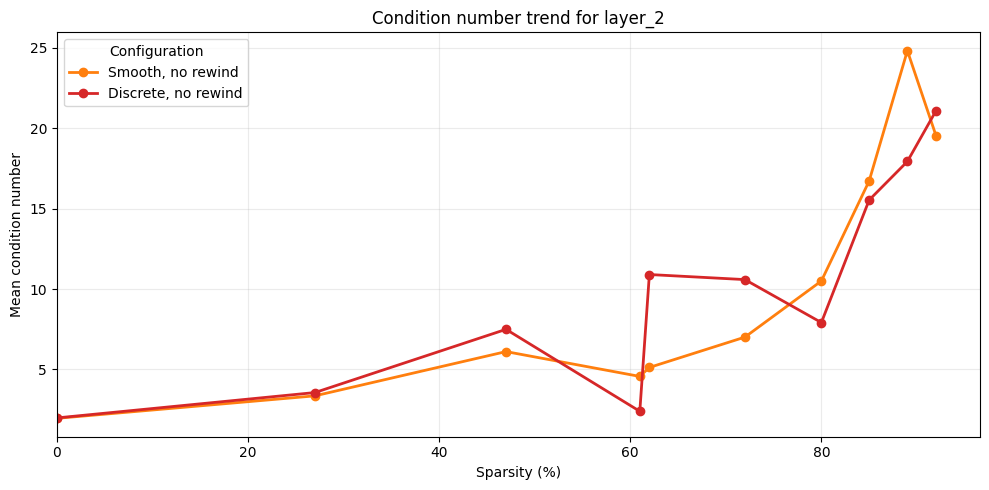

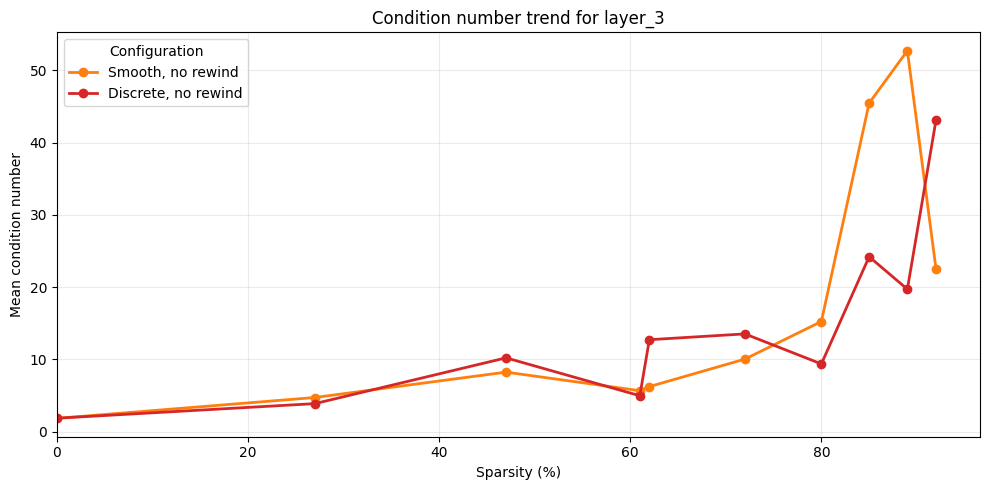

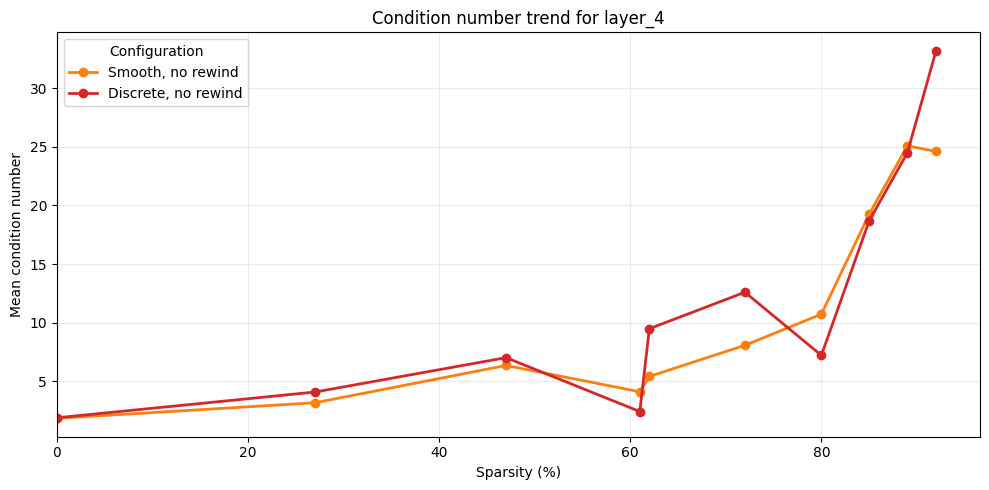

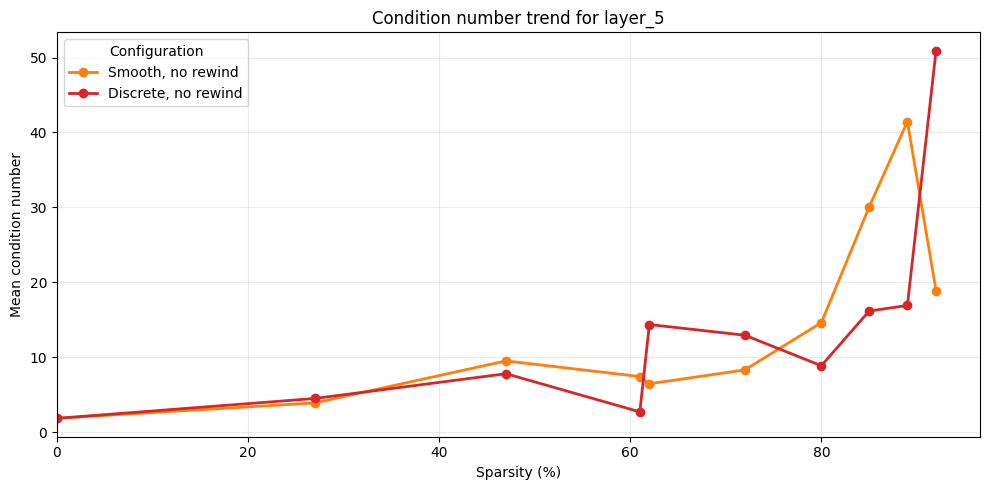

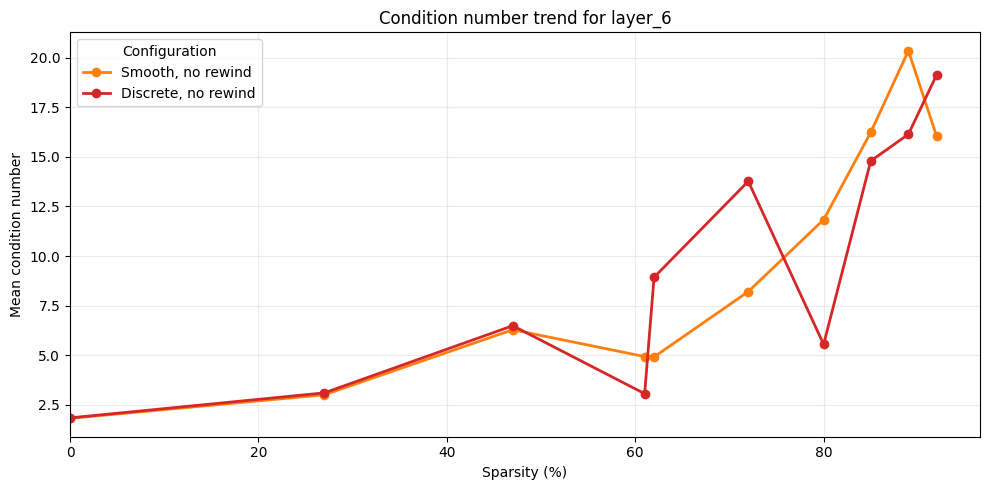

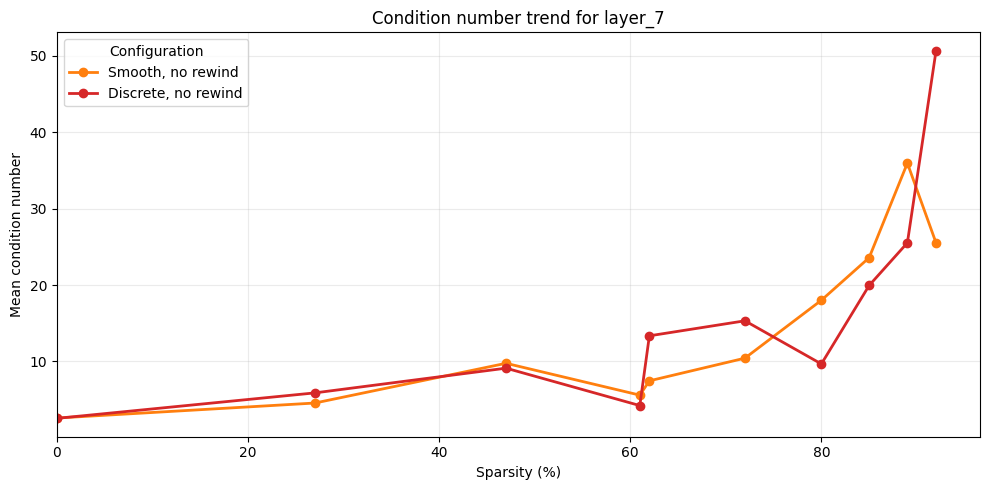

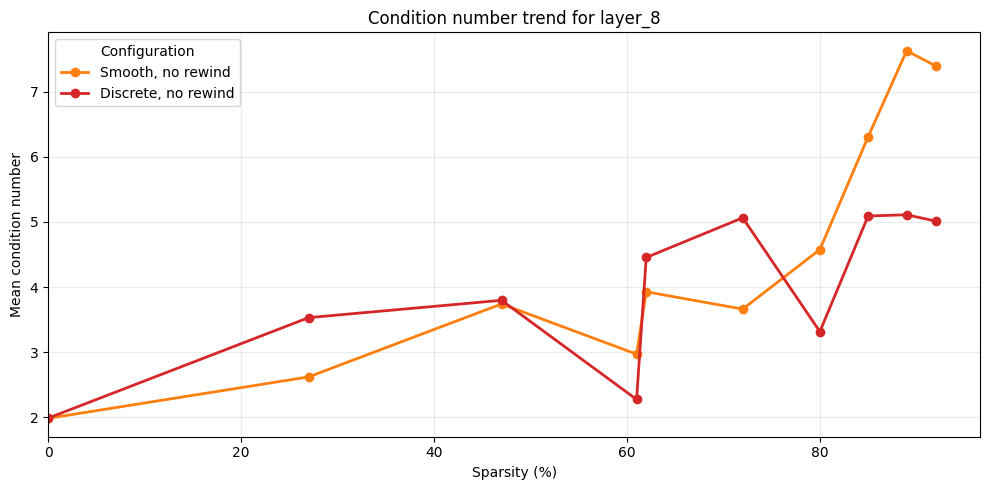

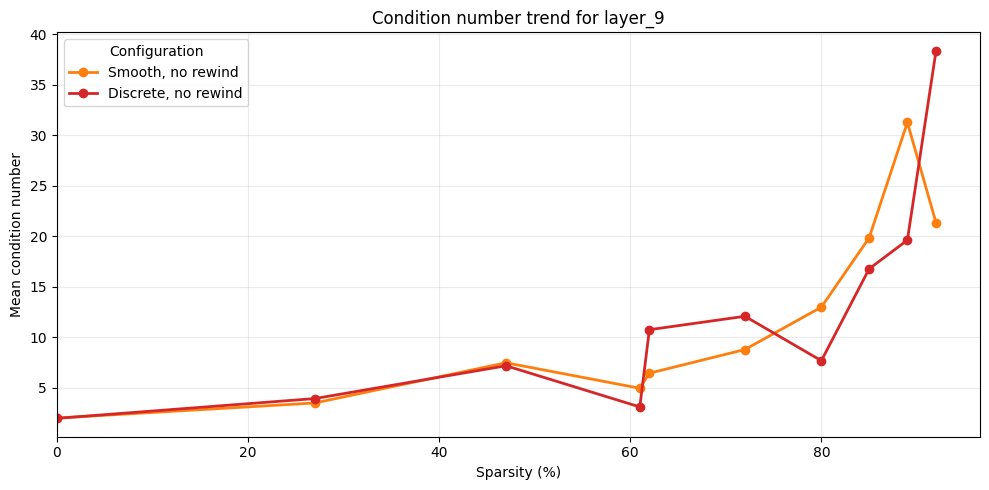

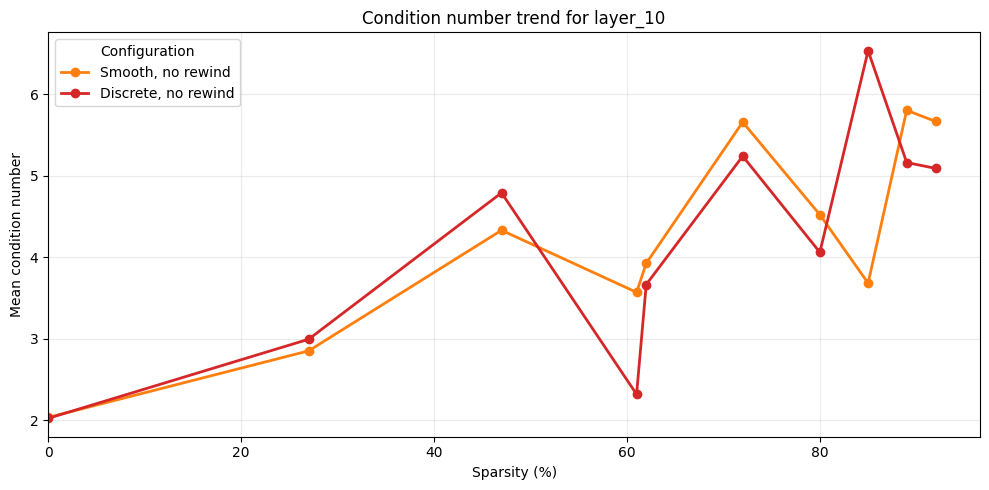

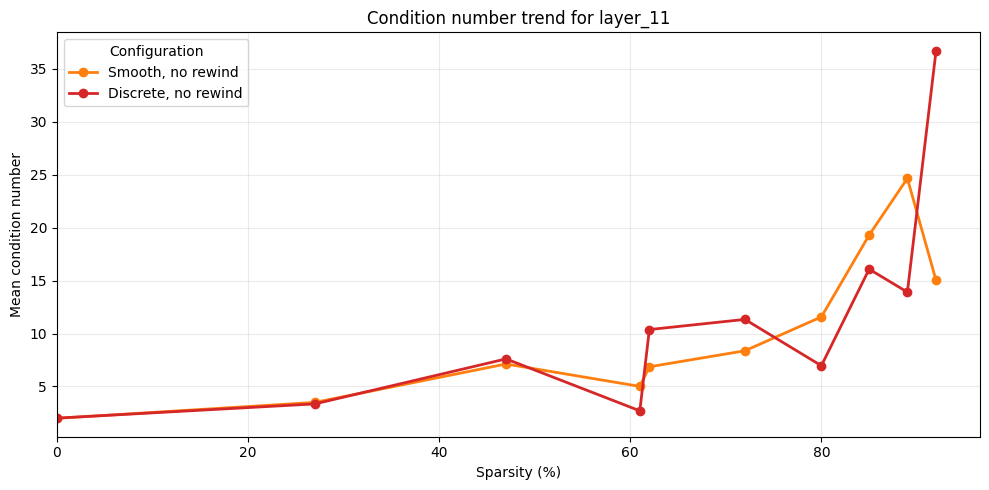

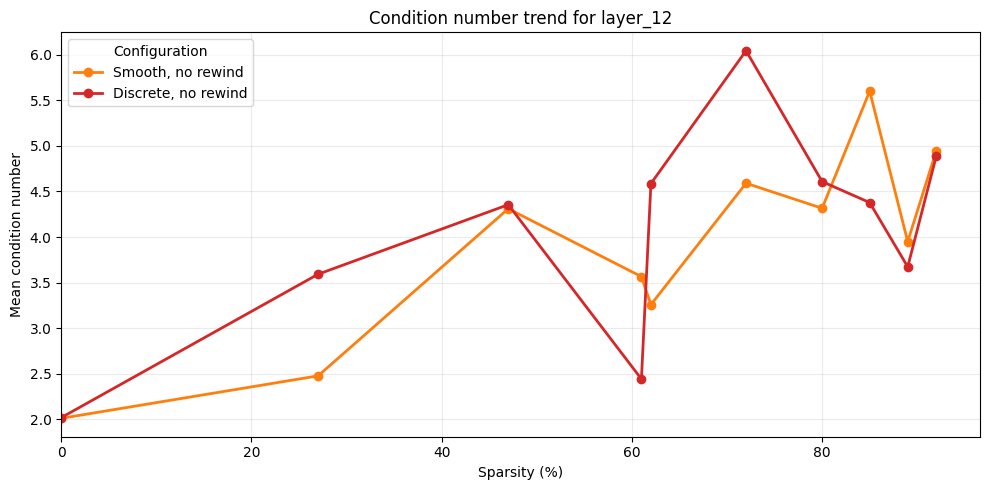

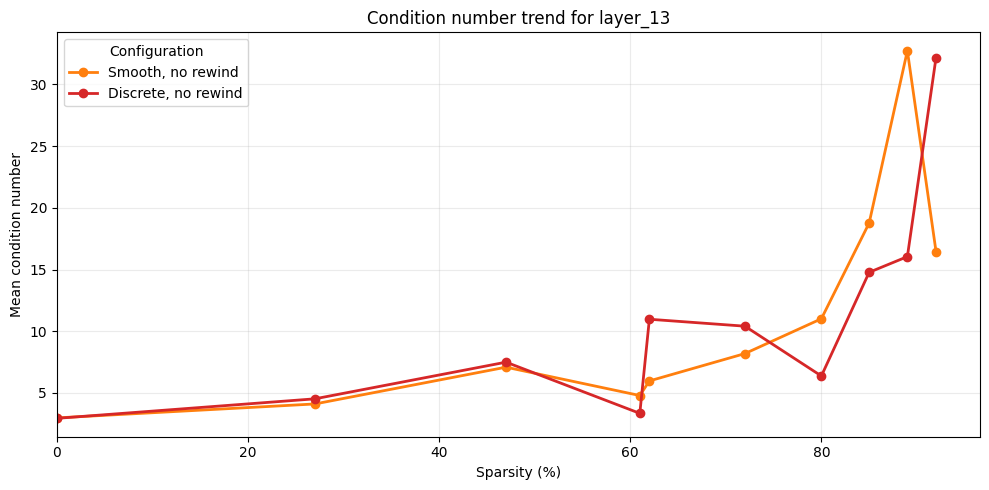

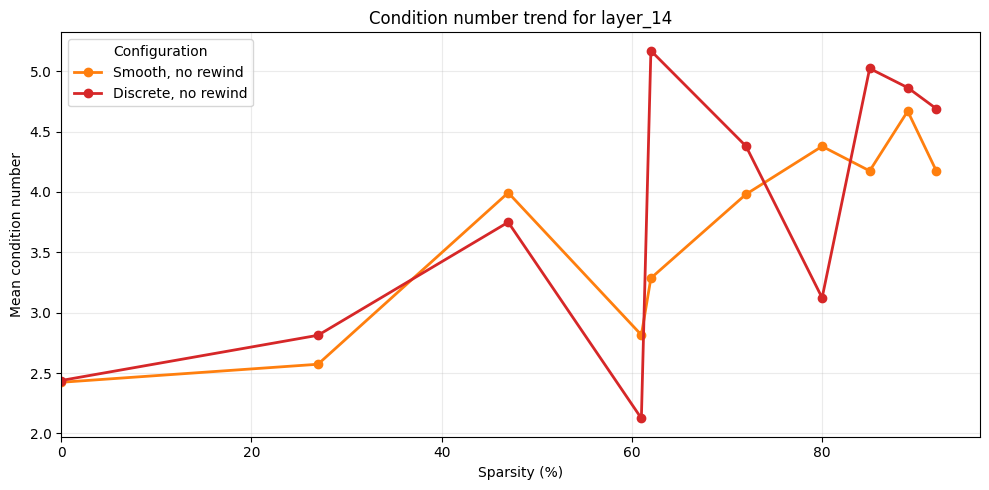

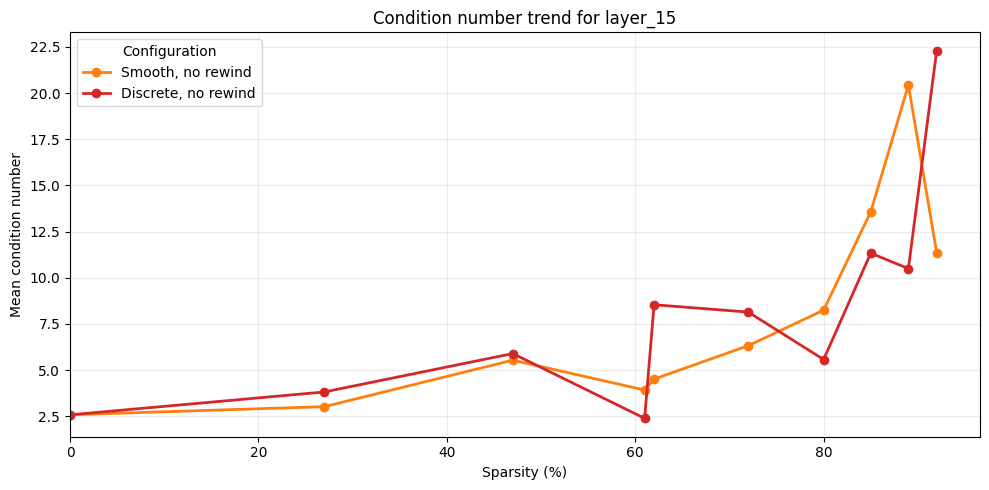

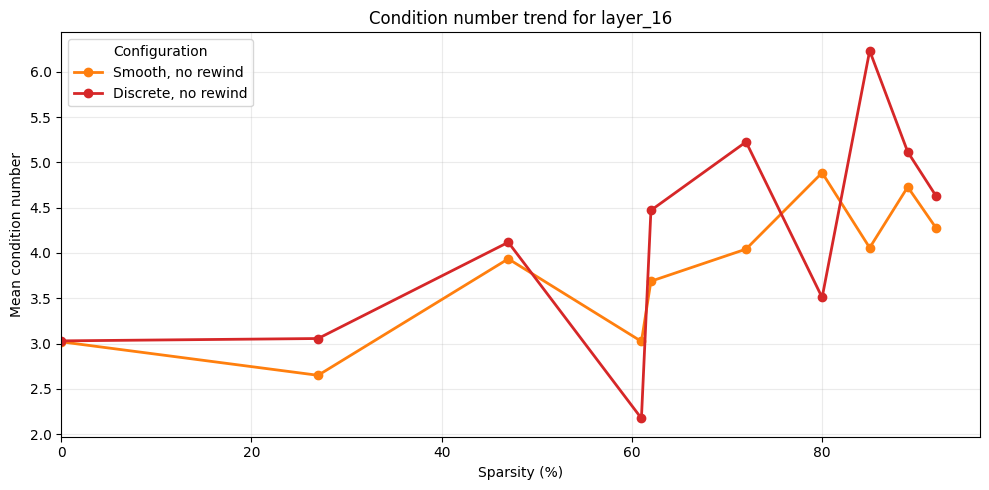

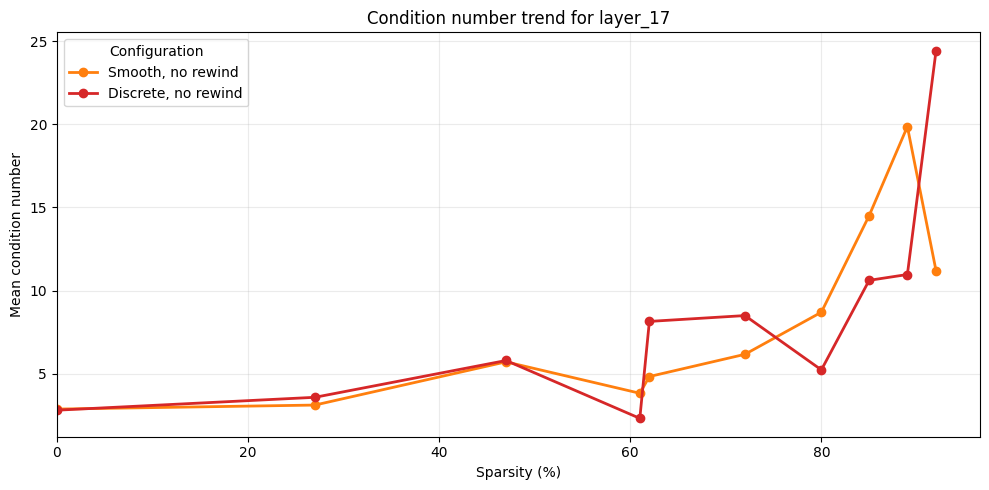

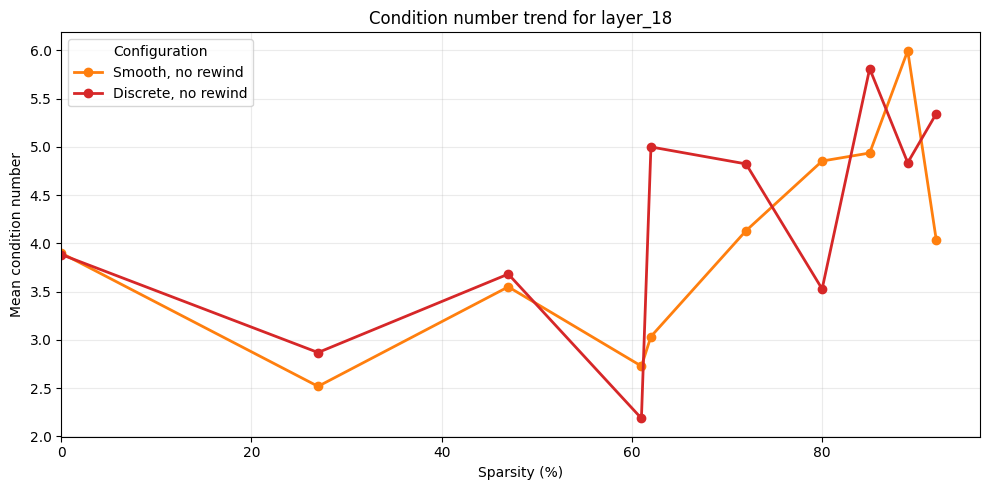

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

checkpoint_df = pd.read_csv("../results/resnet20_pruning_all_checkpoints.csv").copy()

checkpoint_df["sparsity_group"] = checkpoint_df["sparsity"].round(0).clip(lower=0.0)

layer_cols = sorted(
    [col for col in checkpoint_df.columns if col.startswith("layer_")],
    key=lambda name: int(name.split("_")[1]),
)

configs = ["smooth_no_rewind", "static_no_rewind"]
config_labels = {
    "smooth_no_rewind": "Smooth, no rewind",
    "static_no_rewind": "Discrete, no rewind",
}
config_colors = {
    "smooth_no_rewind": "tab:orange",
    "static_no_rewind": "tab:red",
}

for layer_col in layer_cols:
    summary = (
        checkpoint_df[checkpoint_df["configuration"].isin(configs)]
        .groupby(["configuration", "sparsity_group"], as_index=False)
        .agg(
            mean_condition_number=(layer_col, "mean"),
            std_condition_number=(layer_col, lambda values: values.std(ddof=1)),
            num_points=(layer_col, "size"),
        )
        .sort_values(["configuration", "sparsity_group"])
    )

    fig, ax = plt.subplots(figsize=(10, 5))

    for config_name in configs:
        config_df = summary[summary["configuration"] == config_name].sort_values("sparsity_group")
        if config_df.empty:
            continue

        x = config_df["sparsity_group"].to_numpy()
        y = config_df["mean_condition_number"].to_numpy()

        ax.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            color=config_colors[config_name],
            label=config_labels[config_name],
        )

    ax.set_title(f"Condition number trend for {layer_col}")
    ax.set_xlabel("Sparsity (%)")
    ax.set_ylabel("Mean condition number")
    ax.set_xlim(left=0)
    ax.grid(True, alpha=0.25)
    ax.legend(title="Configuration")
    plt.tight_layout()
    plt.show()

## Epsilon and lambda impact

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_final_distributions_row(filepath, baseline_eps=1e-6, baseline_lam=0.01, x_lim=(-0.001, 0.001)):
    target_eps_key = f"eps_{baseline_eps:.1e}"
    target_lam_key = f"lam_{baseline_lam:.4f}"
    xs = np.linspace(x_lim[0], x_lim[1], 1000)

    def parse_val(key):
        return float(key.split('_')[1])

    with h5py.File(filepath, 'r') as f:
        # 1. Gather all configurations to plot
        configs_to_plot = []
        
        all_eps = sorted(list(f.keys()))
        # strip eps or lam keys to just the numeric values for comparison
        # this ensures we can find the target keys even if the exact formatting differs (e.g., different number of decimal places)
        new_all_eps = []
        new_all_lam = []
        for eps in all_eps:
            if eps.startswith("eps_"):
                eps_value = float(eps.split("_")[1])
                new_all_eps.append(eps_value)
            elif eps.startswith("lam_"):
                lam_value = float(eps.split("_")[1])
                new_all_lam.append(lam_value)

        if target_eps_key not in all_eps:
            raise ValueError(f"Could not find baseline epsilon '{target_eps_key}'.")
            
        all_lam = sorted(list(f[target_eps_key].keys()))

        for eps in all_eps:
            if target_lam_key in f[eps]:
                configs_to_plot.append((eps, target_lam_key, f"Epsilon = {eps}"))
        
        #for lam in all_lam:
        #    if lam != target_lam_key and lam in f[target_eps_key]:
        #        configs_to_plot.append((target_eps_key, lam, f"Lambda = {lam}"))

        # 2. Setup the Figure with a Shared Y-Axis
        num_plots = 1 + len(configs_to_plot)
        # sharey=True guarantees all spikes are evaluated on the exact same vertical scale
        fig, axes = plt.subplots(1, num_plots, figsize=(4 * num_plots, 5), sharey=True)
        
        def draw_dist(ax, weights, title, is_step_zero=False):
            if len(weights) == 0:
                return
                
            if np.std(weights) < 1e-4:
                weights = weights + np.random.normal(0, 1e-4, size=weights.shape)
                
            try:
                kde = gaussian_kde(weights)
                kde.set_bandwidth(bw_method=kde.factor / 4.0)
                ys = kde(xs)
            except np.linalg.LinAlgError:
                ys = np.zeros_like(xs)
            
            ys_log = np.log1p(ys)
            
            color = '#4C72B0' if is_step_zero else '#C44E52'
            
            ax.fill_between(xs, 0, ys_log, facecolor=color, alpha=0.7)
            ax.plot(xs, ys_log, color='black', linewidth=1.5)
            
            ax.set_title(title, fontweight='bold', pad=15)
            ax.set_xlabel('Weight Value')
            ax.set_xlim(x_lim[0], x_lim[1])
            ax.set_ylim(0, None)
            
            # --- NEW: Grid and Axis adjustments ---
            # Turn on horizontal and vertical dashed grid lines
            ax.grid(True, which='major', linestyle='--', alpha=0.6, color='gray')
            
            # Keep left and bottom spines, hide top and right for cleanliness
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            
            # Only add the Y-axis title to the very first plot to avoid clutter
            if is_step_zero:
                ax.set_ylabel('Log Density (log1p)', fontweight='bold')

        # 3. Plot Step 0 (The Initial Baseline)
        baseline_group = f[target_eps_key][target_lam_key]
        step_0_weights = baseline_group['step_0'][:]
        draw_dist(axes[0], step_0_weights, "Initial Distribution", is_step_zero=True)
        
        # 4. Plot the Final Step for each configuration
        for i, (eps_key, lam_key, title) in enumerate(configs_to_plot):
            group = f[eps_key][lam_key]
            
            step_keys = sorted(list(group.keys()), key=lambda x: int(x.split('_')[1]))
            final_step_key = step_keys[-1]
            
            weights = group[final_step_key][:]
            draw_dist(axes[i + 1], weights, title)

    plt.tight_layout()
    plt.show()


import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_final_distributions_grid(filepath, baseline_eps=1e-6, baseline_lam=0.01, x_lim=(-0.001, 0.001)):
    target_eps_key = f"eps_{baseline_eps:.1e}"
    target_lam_key = f"lam_{baseline_lam:.4f}"
    xs = np.linspace(x_lim[0], x_lim[1], 1000)

    # Helper function to extract the raw float from the string key (e.g., "eps_1.0e-06" -> 1.0e-6)
    

    with h5py.File(filepath, 'r') as f:
        # Sort keys numerically rather than alphabetically
        all_eps = sorted(list(f.keys()), key=parse_val)
        if target_eps_key not in all_eps:
            raise ValueError(f"Could not find baseline epsilon '{target_eps_key}'.")
            
        all_lam = sorted(list(f[target_eps_key].keys()), key=parse_val)

        # 1. Identify valid variations for both rows
        eps_variations = [eps for eps in all_eps if target_lam_key in f[eps]]
        # Only create a lambda row if there are actual variations beyond the baseline
        lam_variations = [lam for lam in all_lam if lam in f[target_eps_key]]
        
        plot_eps_row = len(eps_variations) > 0
        plot_lam_row = len(lam_variations) > 1 

        num_rows = (1 if plot_eps_row else 0) + (1 if plot_lam_row else 0)
        
        if num_rows == 0:
            print("No data found to plot.")
            return

        # Determine the maximum columns needed (+1 for the Step 0 anchor on the left)
        cols = max(len(eps_variations) + 1 if plot_eps_row else 0,
                   len(lam_variations) + 1 if plot_lam_row else 0)

        # squeeze=False ensures 'axes' is always a 2D array, even if num_rows is 1
        fig, axes = plt.subplots(num_rows, cols, figsize=(4 * cols, 5 * num_rows), 
                                 sharey=True, squeeze=False)
        
        def draw_dist(ax, weights, title, is_step_zero=False):
            if len(weights) == 0:
                ax.axis('off')
                return
                
            if np.std(weights) < 1e-4:
                weights = weights + np.random.normal(0, 1e-4, size=weights.shape)
                
            try:
                kde = gaussian_kde(weights)
                kde.set_bandwidth(bw_method=kde.factor / 4.0)
                ys = kde(xs)
            except np.linalg.LinAlgError:
                ys = np.zeros_like(xs)
            
            ys_log = np.log1p(ys)
            
            color = '#4C72B0' if is_step_zero else '#C44E52'
            
            ax.fill_between(xs, 0, ys_log, facecolor=color, alpha=0.7)
            ax.plot(xs, ys_log, color='black', linewidth=1.5)
            
            ax.set_title(title, fontweight='bold', pad=15)
            ax.set_xlabel('Weight Value')
            ax.set_xlim(x_lim[0], x_lim[1])
            
            ax.grid(True, which='major', linestyle='--', alpha=0.6, color='gray')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            
            if is_step_zero:
                ax.set_ylabel('Log Density (log1p)', fontweight='bold')

        # Grab the baseline Step 0 weights to use as the anchor for both rows
        baseline_group = f[target_eps_key][target_lam_key]
        step_0_weights = baseline_group['step_0'][:]

        current_row = 0

        # --- Row 1: Epsilon Variations ---
        if plot_eps_row:
            draw_dist(axes[current_row, 0], step_0_weights, "Initial Distribution", is_step_zero=True)
            
            for i, eps_key in enumerate(eps_variations):
                group = f[eps_key][target_lam_key]
                step_keys = sorted(list(group.keys()), key=lambda x: int(x.split('_')[1]))
                weights = group[step_keys[-1]][:]
                
                # Format clean numeric title
                val_eps = parse_val(eps_key)
                val_lam = parse_val(target_lam_key)
                title = f"Epsilon = {val_eps:.1}"
                
                draw_dist(axes[current_row, i + 1], weights, title)
            
            # Hide any unused subplots on the right side of this row
            for j in range(len(eps_variations) + 1, cols):
                axes[current_row, j].axis('off')
                
            current_row += 1

        # --- Row 2: Lambda Variations ---
        if plot_lam_row:
            #draw_dist(axes[current_row, 0], step_0_weights, "Initial State\n(Step 0)", is_step_zero=True)
            
            for i, lam_key in enumerate(lam_variations):
                group = f[target_eps_key][lam_key]
                step_keys = sorted(list(group.keys()), key=lambda x: int(x.split('_')[1]))
                weights = group[step_keys[-1]][:]
                
                # Format clean numeric title
                val_lam = parse_val(lam_key)
                val_eps = parse_val(target_eps_key)
                title = f"Lambda = {val_lam:.4f}"
                
                draw_dist(axes[current_row, i + 1], weights, title)
                
            # Hide any unused subplots on the right side of this row
            for j in range(len(lam_variations) + 1, cols):
                axes[current_row, j].axis('off')

    plt.tight_layout()
    plt.show()

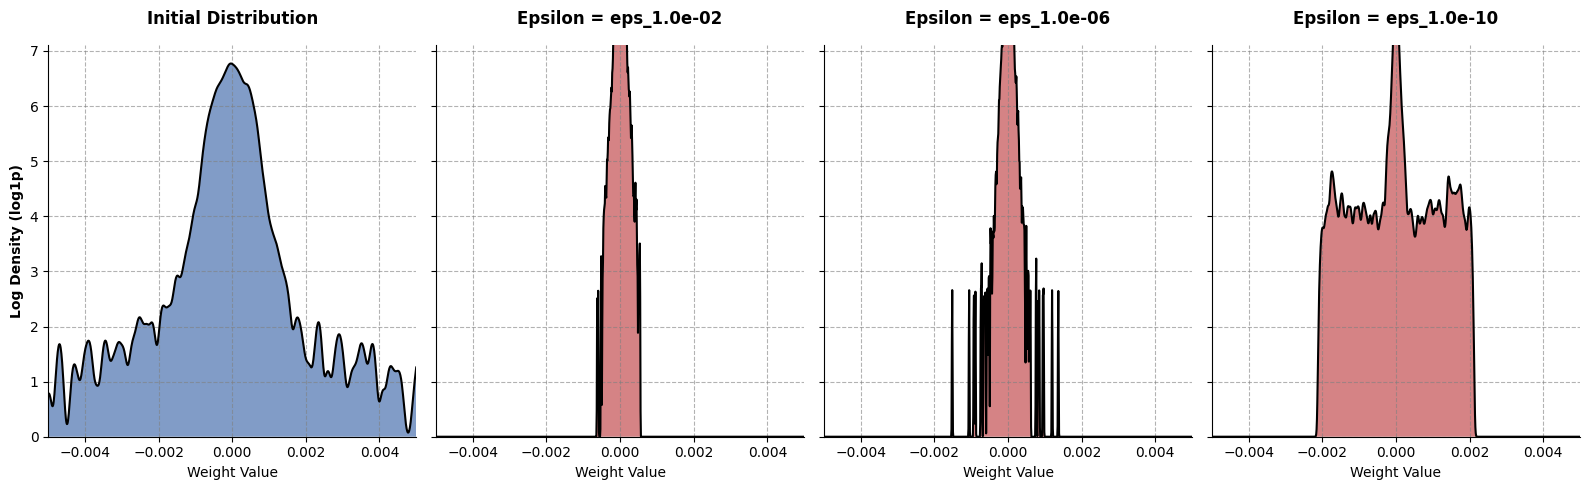

In [104]:
plot_final_distributions_row("../results/waterfall_weight.h5", x_lim=(-0.005, 0.005))

In [100]:
import h5py

def inspect_h5(filepath):
    with h5py.File(filepath, 'r') as f:
        print(f"--- Contents of {filepath} ---")
        for eps_key in f.keys():
            print(f"Epsilon group: '{eps_key}'")
            for lam_key in f[eps_key].keys():
                steps = list(f[eps_key][lam_key].keys())
                print(f"  -> Lambda group: '{lam_key}' | Steps logged: {len(steps)}")

inspect_h5("../results/waterfall_weight.h5")

--- Contents of ../results/waterfall_weight.h5 ---
Epsilon group: 'eps_1.0e-02'
  -> Lambda group: 'lam_0.0100' | Steps logged: 6
Epsilon group: 'eps_1.0e-06'
  -> Lambda group: 'lam_0.0010' | Steps logged: 10
  -> Lambda group: 'lam_0.0100' | Steps logged: 8
  -> Lambda group: 'lam_1.0000' | Steps logged: 8
  -> Lambda group: 'lam_10.0000' | Steps logged: 9
Epsilon group: 'eps_1.0e-10'
  -> Lambda group: 'lam_0.0100' | Steps logged: 8
